## Perceptron code

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import os

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

class Perceptron():

    def __init__(self, layers, activation = "sigmoid"):
        self.activation = activation
        self.w = [[] for i in range(len(layers))]
        self.layers = layers
        self.l = len(layers)
        self.w[0] = np.zeros(1) #zeroth is empty
        for i in range(1,len(layers)):
            self.w[i] = np.zeros((layers[i-1],layers[i]))
        print("W")
        print([wi.shape for wi in self.w])
        print()


    def step(self, x):
        if x>0:
            return 1
        else:
            return 0
        
    def addBias(self, y, k,yb):
        res =  np.zeros(self.layers[k])
        return res
      
    def subBias(self, v):
        res =  np.zeros(self.layers[k])
        return res
        
    def activate(self, xh):
        yb = xh
        y =  [[] for i in range(self.l-1)]
        for k in range(1,self.l):
            y[k-1] = self.addBias(y,k-1,yb)
            yb = np.dot(y[k-1],self.w[k])
            if self.activation == "sigmoid":
                yb = sigmoid(yb)
            elif self.activation == "step":
                yb = [self.step(s) for s in yb]
        y.append(np.array(yb))
        return y


    def correction(self,nu,y,zh):
            e = zh-y[self.l-1]
            dw =  [[] for i in range(self.l-1)]
            d =  [0 for i in range(self.l)]
            dy = 1-y[-1]*y[-1]
            d[self.l-1] = e*dy
            for k in range(self.l,-1,1):
                dw[k] = self.nu*(y[k-1].T*d[k])
                e = d[k]*w[k].T
                dy = 1-y[k-1]*y[k-1]
                d[k-1] = subBias(e*dy)
            #xh = xh.reshape(len(xh),1) #can't transpose unidimentional nparray.
            #dw = nu*(xh*eh)
            return dw
        
    def predict(self, x):
        x = np.append(x,[-1])
        return self.activate(x)
    
    def train(self, x, z, epochs=100, nu=0.01, epsilon = 0.001):
        bias_row = np.zeros(x.shape[0])-1
        bias_row = [[i] for i in bias_row]
        x = np.append(x,bias_row, axis = 1)
        p = x.shape[0]
        t=1
        err = []
        while t < epochs:
            e = 0
            for h in range(p):
                y = self.activate(x[h])
                dw = self.correction(nu,y,z[h])
                self.w += dw
            err.append(np.linalg.norm(y[-1]-z[h]))

            t+=1
        return err

## Example 1: AND-OR-NAND gate

W
[(1,), (3, 5), (5, 5), (5, 5), (5, 5), (5, 3)]



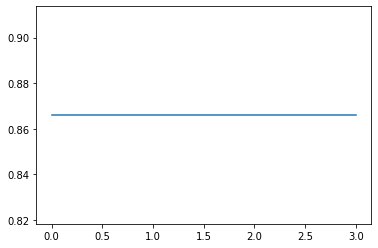

In [6]:
# n = 2 (input size)
# m = 3 (output size)
# p = 8 (#examples)

x = np.array([[1,1], [1,-1],[-1,1],[-1,-1],[1,1], [1,-1],[-1,1],[-1,-1]])
z = np.array([[1, 0, 0, 0,1, 0, 0, 0],[1, 1, 1, 0,1, 1, 1, 0],[0, 1, 1, 1,0, 1, 1, 1]]).T
s = np.array([3,5,5,5,5,3]) #4 capas ocultas

p = Perceptron(s, activation = "sigmoid")

err = p.train(x, z, epochs=5, nu=0.01)

plt.plot(err)

#for i in range(len(x)):
#        print(str(p.predict(x[i])) + " =? " + str(z[i][0]) + str(z[i][1]) + str(z[i][2]))
